## CO2 Emission Case Study
# Problem statement:

The Global Automotive Council aims to understand the key factors influencing vehicle CO₂ emissions and explore data-driven strategies for emission reduction.
A dataset containing detailed information on vehicle specifications, engine characteristics, fuel types, and emission levels has been provided.

The objective is to analyze this dataset to uncover hidden patterns, identify the major contributors to CO₂ emissions, and develop predictive models to support policy and design decisions in the automotive sector.

Dataset link: Link

To download the dataset
Click the link above.
Right-click on an empty area and select “Save As.”
Choose your preferred download location, enter a relevant dataset name, add the “.csv” extension, and click Save.
Dataset description: Link

Approach Document: CO2 Case Study Approach Document

# CO₂ Emission Prediction using Supervised Machine Learning

## Business Problem

The Global Automotive Council aims to identify the major factors influencing vehicle CO₂ emissions and develop a predictive model to estimate emission levels based on vehicle specifications.

### Objectives

- Understand the dataset and identify important variables.
- Perform data cleaning and preprocessing.
- Analyze relationships between vehicle characteristics and CO₂ emissions.
- Detect multicollinearity among fuel consumption variables.
- Develop an interpretable regression model.
- Evaluate model performance.
- Generate actionable recommendations for reducing vehicle emissions.

Imports & Dataset Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

from google.colab import files

uploaded=files.upload()

filename=list(uploaded.keys())[0]

df=pd.read_csv(filename)

print("Dataset Shape :",df.shape)

display(df.head())

print(df.info())

print(df.isnull().sum())

print("Duplicate Rows :",df.duplicated().sum())

Saving CO2_Emissions.csv to CO2_Emissions.csv
Dataset Shape : (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

Cleaning + EDA

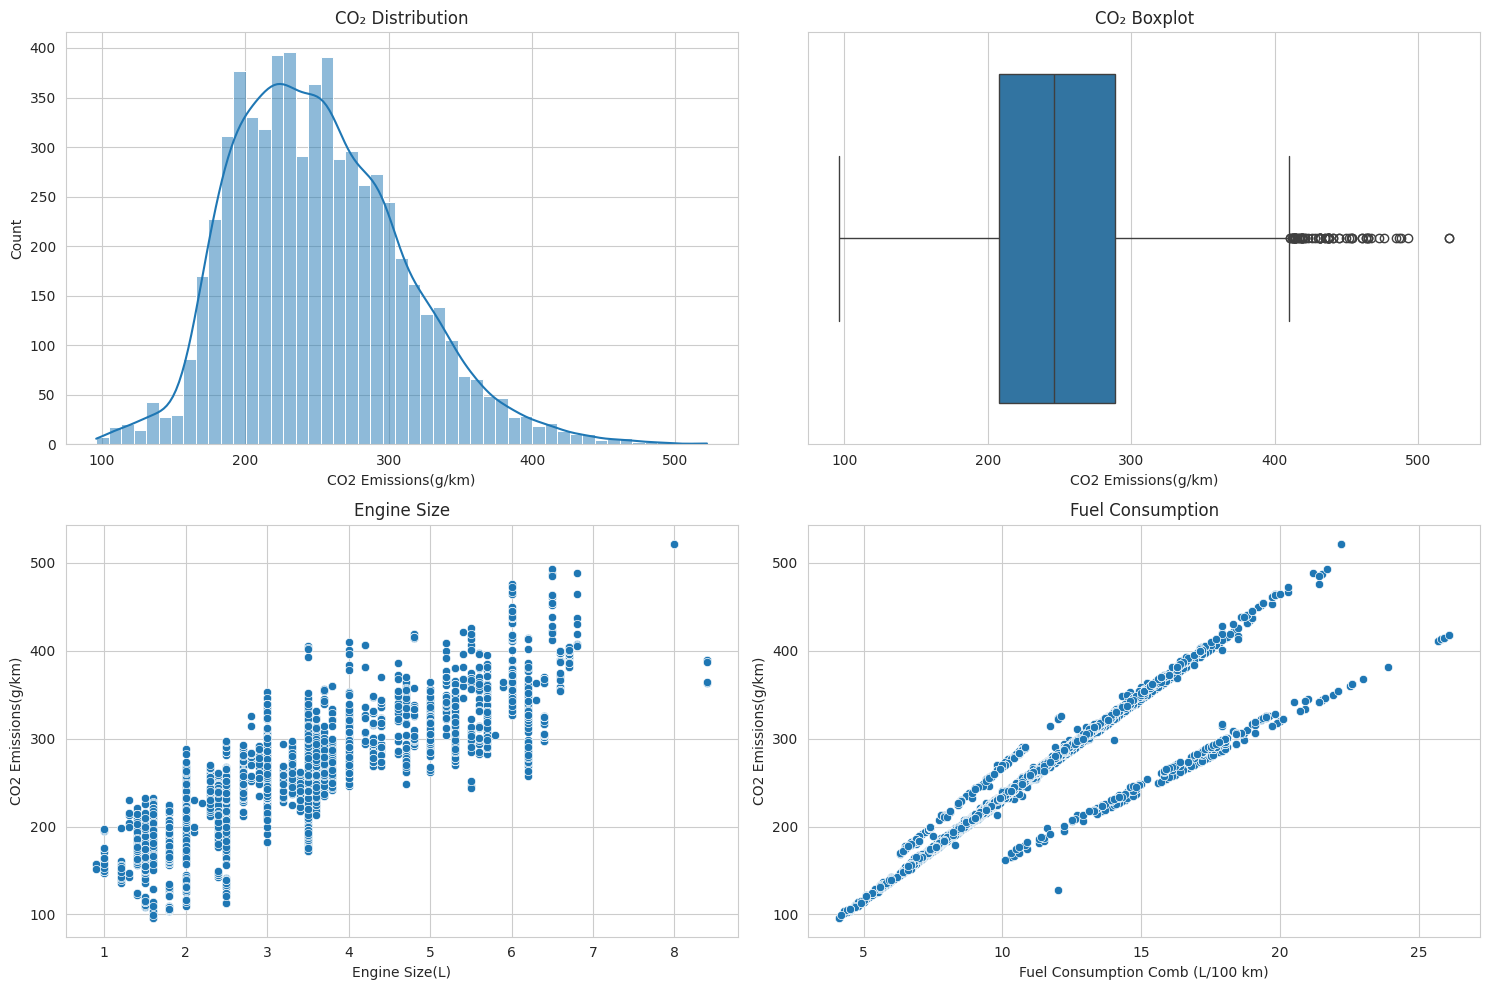

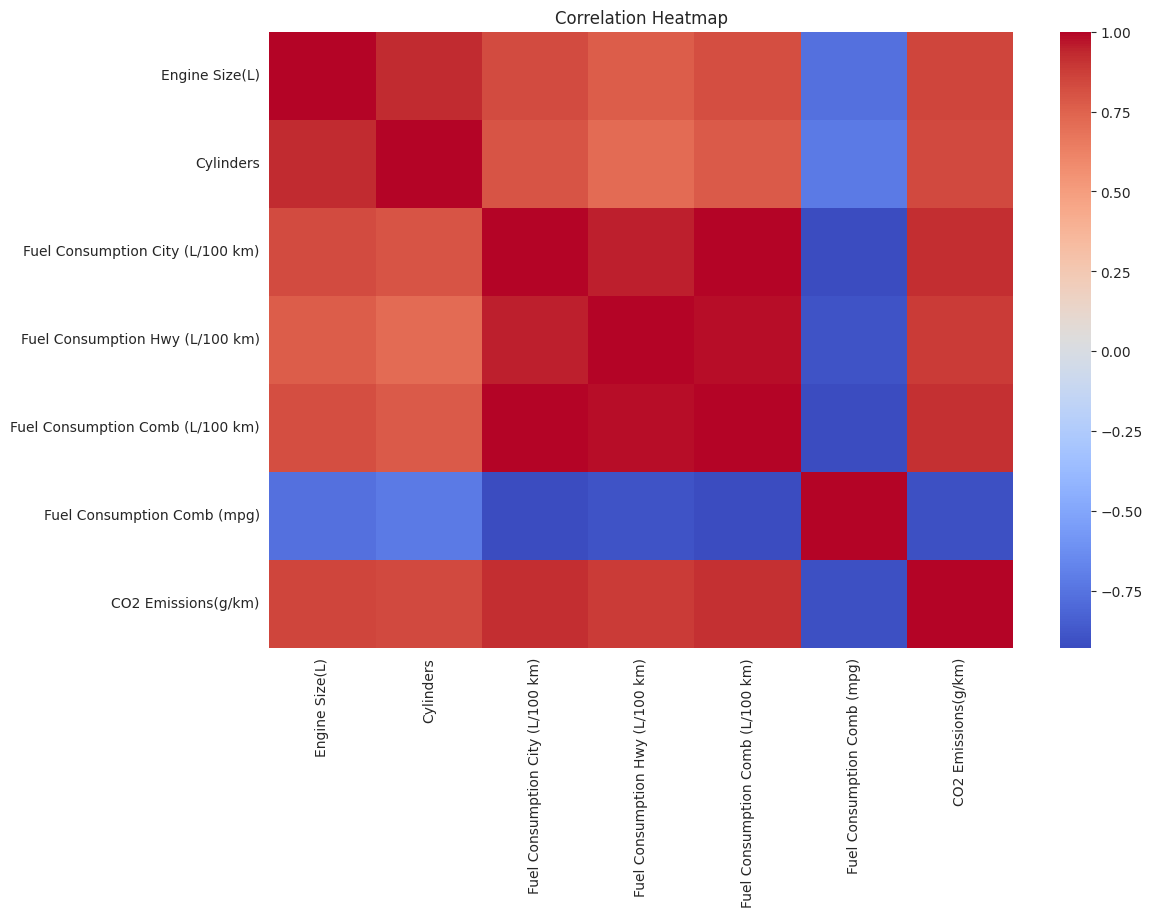

In [2]:
df=df.drop_duplicates()

num_cols=df.select_dtypes(include=np.number).columns

cat_cols=df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

fig,ax=plt.subplots(2,2,figsize=(15,10))

sns.histplot(
    df["CO2 Emissions(g/km)"],
    kde=True,
    ax=ax[0,0]
)

ax[0,0].set_title("CO₂ Distribution")

sns.boxplot(
    x=df["CO2 Emissions(g/km)"],
    ax=ax[0,1]
)

ax[0,1].set_title("CO₂ Boxplot")

sns.scatterplot(
    data=df,
    x="Engine Size(L)",
    y="CO2 Emissions(g/km)",
    ax=ax[1,0]
)

ax[1,0].set_title("Engine Size")

sns.scatterplot(
    data=df,
    x="Fuel Consumption Comb (L/100 km)",
    y="CO2 Emissions(g/km)",
    ax=ax[1,1]
)

ax[1,1].set_title("Fuel Consumption")

plt.tight_layout()

plt.show()

plt.figure(figsize=(12,8))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

Outliers + Fuel Type + Vehicle Class

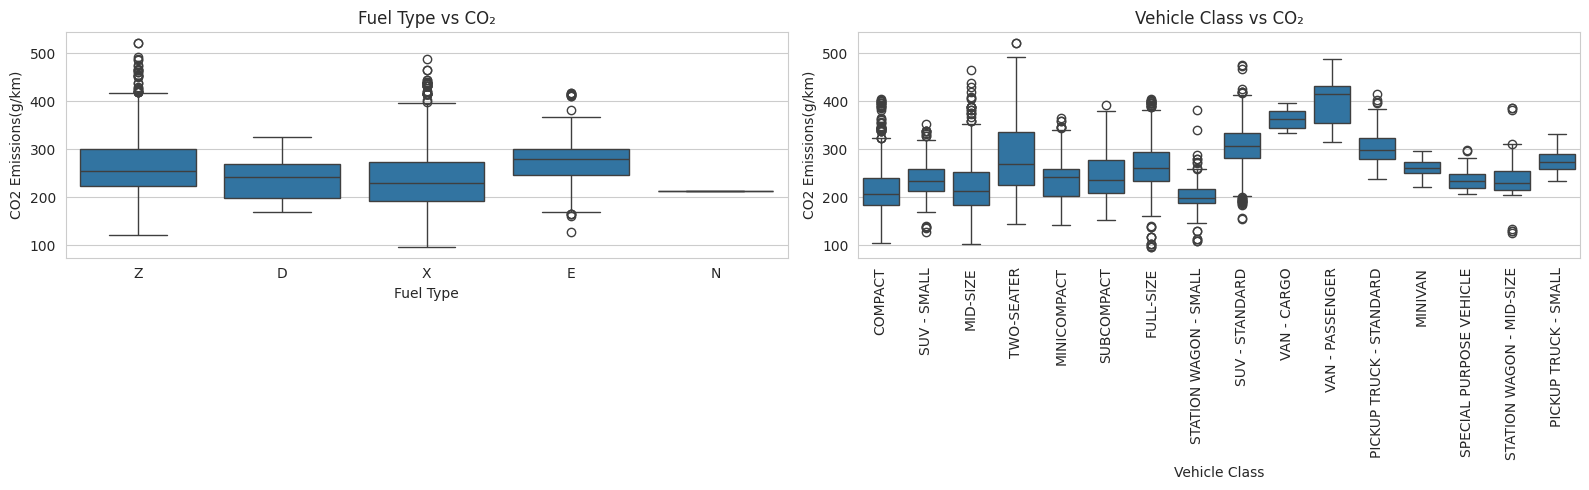

Number of Outliers : 74


In [3]:
fig,ax=plt.subplots(1,2,figsize=(16,5))

sns.boxplot(
    data=df,
    x="Fuel Type",
    y="CO2 Emissions(g/km)",
    ax=ax[0]
)

ax[0].set_title("Fuel Type vs CO₂")

sns.boxplot(
    data=df,
    x="Vehicle Class",
    y="CO2 Emissions(g/km)",
    ax=ax[1]
)

ax[1].tick_params(axis="x",rotation=90)

ax[1].set_title("Vehicle Class vs CO₂")

plt.tight_layout()

plt.show()

Q1=df["CO2 Emissions(g/km)"].quantile(.25)
Q3=df["CO2 Emissions(g/km)"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[
    (df["CO2 Emissions(g/km)"]<lower)|
    (df["CO2 Emissions(g/km)"]>upper)
]

print("Number of Outliers :",len(outliers))

Multicollinearity (VIF)

In [4]:
vif_df=df.select_dtypes(include=np.number).drop(
    columns=["CO2 Emissions(g/km)"]
)

vif_df=vif_df.dropna()

X=sm.add_constant(vif_df)

vif=pd.DataFrame()

vif["Feature"]=X.columns

vif["VIF"]=[

    variance_inflation_factor(
        X.values,
        i
    )

    for i in range(X.shape[1])

]

display(vif.sort_values("VIF",ascending=False))

print("""
If VIF > 10,
remove highly correlated fuel consumption variables
before training the regression model.
""")

,Feature,VIF
5,Fuel Consumption Comb (L/100 km),5045.257775
3,Fuel Consumption City (L/100 km),2225.278475
4,Fuel Consumption Hwy (L/100 km),623.629777
0,const,390.529451
1,Engine Size(L),8.757645
2,Cylinders,7.723823
6,Fuel Consumption Comb (mpg),7.274915



If VIF > 10,
remove highly correlated fuel consumption variables
before training the regression model.



# Data Preprocessing & Regression Model Development

After completing exploratory analysis, the dataset is prepared for regression modeling.

The preprocessing pipeline includes:

- Removing multicollinearity
- Encoding categorical variables
- Scaling numerical features
- Train-Test Split
- Multiple Regression Models
- Cross Validation
- Model Comparison using MAE, RMSE and R²

Preprocessing

In [5]:
# Remove highly collinear variables (based on VIF)

drop_cols = [
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=["CO2 Emissions(g/km)"])

y = df_model["CO2 Emissions(g/km)"]

categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",

            Pipeline([

                ("imputer",SimpleImputer(strategy="median")),

                ("scaler",StandardScaler())

            ]),

            numerical_features

        ),

        (

            "cat",

            Pipeline([

                ("imputer",SimpleImputer(strategy="most_frequent")),

                ("encoder",OneHotEncoder(handle_unknown="ignore"))

            ]),

            categorical_features

        )

    ]

)

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(5025, 8)
(1257, 8)


Train All Regression Models

In [6]:
models={

    "Linear Regression":

        LinearRegression(),

    "Ridge Regression":

        Ridge(alpha=1.0),

    "Lasso Regression":

        Lasso(alpha=0.01),

    "Random Forest":

        RandomForestRegressor(

            random_state=42,

            n_estimators=300

        )

}

results=[]

trained_models={}

cv=KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

for name,model in models.items():

    pipe=Pipeline([

        ("preprocessor",preprocessor),

        ("model",model)

    ])

    cv_r2=cross_val_score(

        pipe,

        X_train,

        y_train,

        cv=cv,

        scoring="r2"

    )

    pipe.fit(

        X_train,

        y_train

    )

    pred=pipe.predict(X_test)

    mae=mean_absolute_error(

        y_test,

        pred

    )

    rmse=np.sqrt(

        mean_squared_error(

            y_test,

            pred

        )

    )

    r2=r2_score(

        y_test,

        pred

    )

    results.append({

        "Model":name,

        "CV R²":cv_r2.mean(),

        "MAE":mae,

        "RMSE":rmse,

        "Test R²":r2

    })

    trained_models[name]=pipe

results=pd.DataFrame(results)

results=results.sort_values(

    "Test R²",

    ascending=False

)

display(results)

,Model,CV R²,MAE,RMSE,Test R²
3,Random Forest,0.996623,2.311271,4.147094,0.995234
1,Ridge Regression,0.991864,3.261672,5.818883,0.990617
2,Lasso Regression,0.992314,3.289614,6.007559,0.989999
0,Linear Regression,0.989575,3.694347,6.392217,0.988677


Hyperparameter Tuning

In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

params = {
    "model__n_estimators":[100,200],
    "model__max_depth":[10,None]
}

grid = GridSearchCV(
    rf_pipeline,
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best CV Score")
print(grid.best_score_)

Best Parameters
{'model__max_depth': 10, 'model__n_estimators': 200}
Best CV Score
0.9968451447390008


Final Evaluation

Best Model : Random Forest
MAE : 2.31
RMSE : 4.15
R² : 0.9952


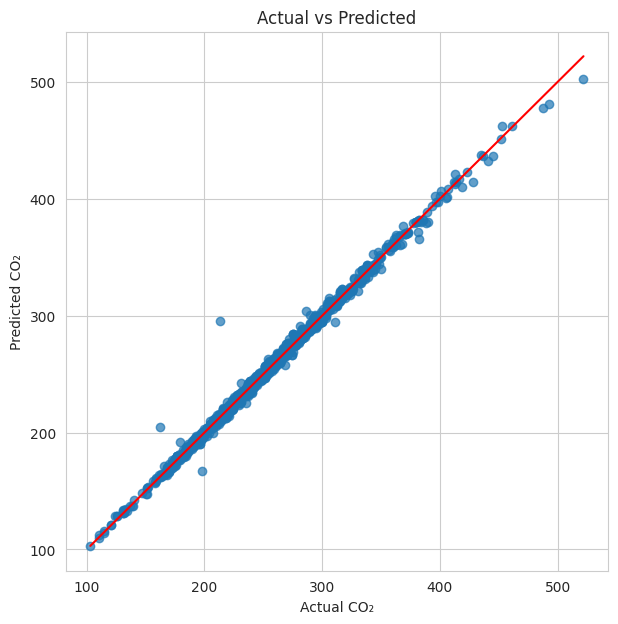

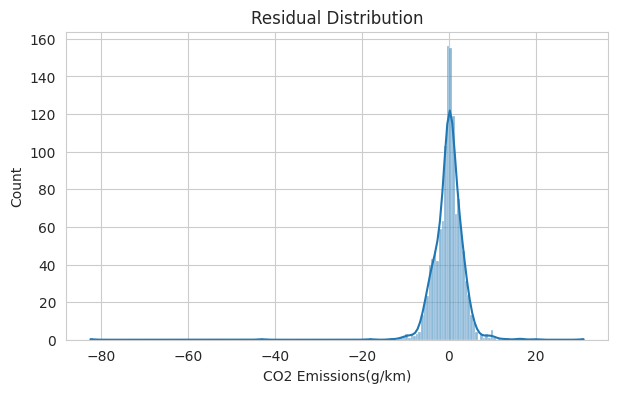

In [9]:
best_model_name=results.iloc[0]["Model"]

best_model=trained_models[best_model_name]

prediction=best_model.predict(X_test)

print("="*70)
print("Best Model :",best_model_name)
print("="*70)

print("MAE :",round(

    mean_absolute_error(

        y_test,

        prediction

    ),2

))

print("RMSE :",round(

    np.sqrt(

        mean_squared_error(

            y_test,

            prediction

        )

    ),2

))

print("R² :",round(

    r2_score(

        y_test,

        prediction

    ),4

))

plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    prediction,

    alpha=0.7

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red"

)

plt.xlabel("Actual CO₂")

plt.ylabel("Predicted CO₂")

plt.title("Actual vs Predicted")

plt.show()

residual=y_test-prediction

plt.figure(figsize=(7,4))

sns.histplot(

    residual,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

# Model Explainability & Business Insights

After selecting the best-performing regression model, the next objective is to understand **why** the model predicts certain emission values.

This section focuses on:

- Feature Importance
- Residual Analysis
- Worst Prediction Analysis
- Business Recommendations
- Executive Summary

These insights help policymakers and automobile manufacturers identify the major contributors to CO₂ emissions and design effective emission reduction strategies.

Feature Importance

,Feature,Importance
2,num__Fuel Consumption Comb (L/100 km),0.938302
1981,cat__Fuel Type_E,0.050500
1980,cat__Fuel Type_D,0.005204
0,num__Engine Size(L),0.002722
886,cat__Model_FOCUS FFV,0.000757
1,num__Cylinders,0.000462
31,cat__Make_MERCEDES-BENZ,0.000097
1969,cat__Transmission_AS7,0.000081
941,cat__Model_GLA 250 4MATIC,0.000064
1968,cat__Transmission_AS6,0.000061


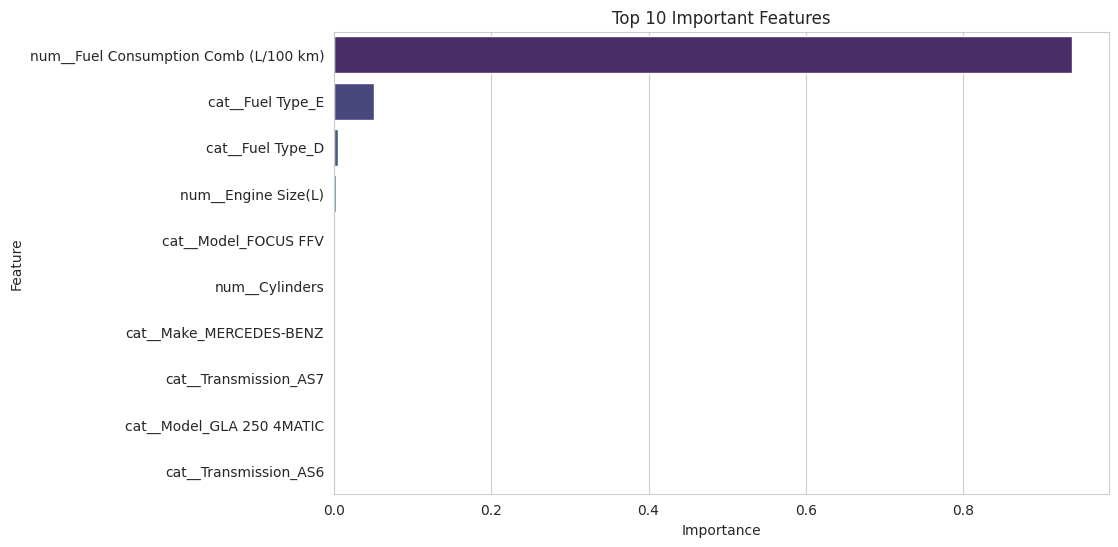

In [10]:
from sklearn.inspection import permutation_importance

best_model = trained_models[best_model_name]

model = best_model.named_steps["model"]

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Tree Model

if hasattr(model,"feature_importances_"):

    importance = model.feature_importances_

# Linear Models

elif hasattr(model,"coef_"):

    importance = np.abs(model.coef_)

# Other Models

else:

    perm = permutation_importance(

        best_model,

        X_test,

        y_test,

        n_repeats=10,

        random_state=42

    )

    importance = perm.importances_mean

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

display(importance_df.head(15))

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 10 Important Features")

plt.show()

Residual & Error Analysis

Worst Predictions


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),Actual,Predicted,Residual,Absolute Error
2439,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,AS6,N,12.7,213,295.508185,-82.508185,82.508185
408,FORD,FOCUS SFE FFV,COMPACT,2.0,4,A6,E,10.1,162,205.080000,-43.080000,43.080000
2990,MERCEDES-BENZ,CLA 250 4MATIC FFV,COMPACT,2.0,4,AS7,E,11.6,198,166.982333,31.017667,31.017667
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,22.2,522,502.170000,19.830000,19.830000
1470,FORD,F-150 FFV,PICKUP TRUCK - STANDARD,5.0,8,AS6,E,17.9,286,304.281556,-18.281556,18.281556
351,FORD,E350 WAGON FFV,VAN - PASSENGER,5.4,8,A4,E,23.9,382,365.413333,16.586667,16.586667
4538,CADILLAC,CTS Vsport,MID-SIZE,3.6,6,AS8,Z,12.7,311,294.861238,16.138762,16.138762
3958,LAMBORGHINI,AVENTADOR COUPE,TWO-SEATER,6.5,12,AM7,Z,17.9,428,414.778889,13.221111,13.221111
4068,MERCEDES-BENZ,B 250,MID-SIZE,2.0,4,AS7,Z,8.3,179,192.063317,-13.063317,13.063317
6046,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,21.7,493,481.213333,11.786667,11.786667


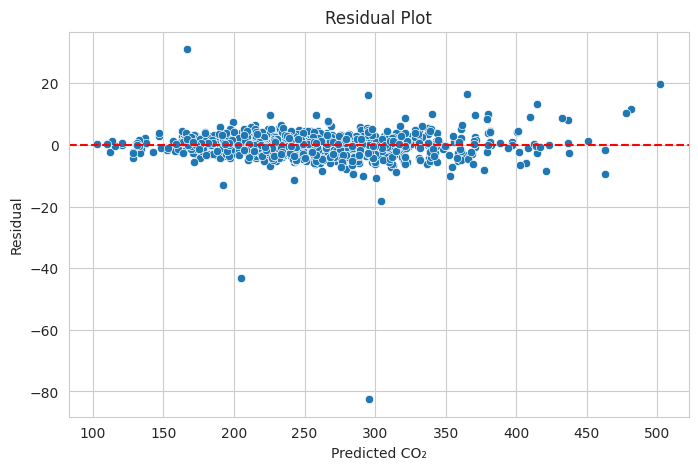

In [11]:
results_df = X_test.copy()

results_df["Actual"] = y_test.values

results_df["Predicted"] = prediction

results_df["Residual"] = results_df["Actual"] - results_df["Predicted"]

results_df["Absolute Error"] = np.abs(results_df["Residual"])

print("="*70)
print("Worst Predictions")
print("="*70)

display(

    results_df

    .sort_values(

        "Absolute Error",

        ascending=False

    )

    .head(10)

)

plt.figure(figsize=(8,5))

sns.scatterplot(

    x=results_df["Predicted"],

    y=results_df["Residual"]

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted CO₂")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Business Insights

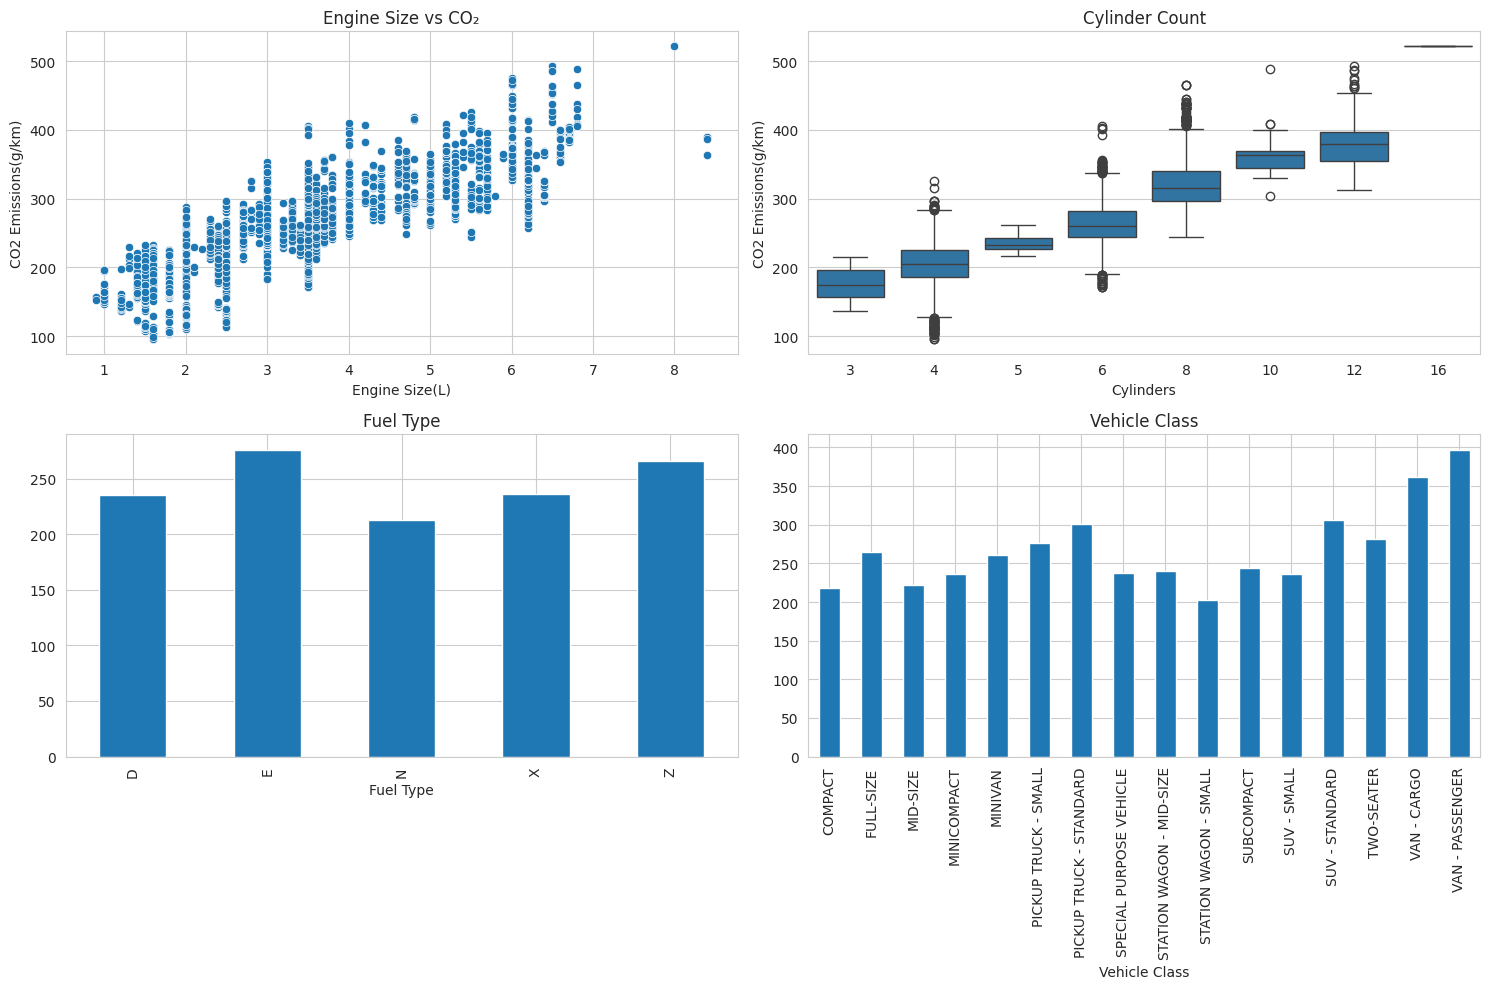

Average CO₂ by Fuel Type


,CO2 Emissions(g/km)
Fuel Type,
N,213.000000
D,235.238095
X,235.977953
Z,265.731284
E,276.048485


Average CO₂ by Vehicle Class


,CO2 Emissions(g/km)
Vehicle Class,
STATION WAGON - SMALL,202.686916
COMPACT,217.641196
MID-SIZE,222.292981
SUV - SMALL,236.413519
MINICOMPACT,236.675182
SPECIAL PURPOSE VEHICLE,237.815385
STATION WAGON - MID-SIZE,240.755556
SUBCOMPACT,244.568480
MINIVAN,261.114754


In [12]:
fig,ax=plt.subplots(2,2,figsize=(15,10))

# Engine Size

sns.scatterplot(

    data=df,

    x="Engine Size(L)",

    y="CO2 Emissions(g/km)",

    ax=ax[0,0]

)

ax[0,0].set_title("Engine Size vs CO₂")

# Cylinders

sns.boxplot(

    data=df,

    x="Cylinders",

    y="CO2 Emissions(g/km)",

    ax=ax[0,1]

)

ax[0,1].set_title("Cylinder Count")

# Fuel Type

fuel=df.groupby(

    "Fuel Type"

)["CO2 Emissions(g/km)"].mean()

fuel.plot(

    kind="bar",

    ax=ax[1,0]

)

ax[1,0].set_title("Fuel Type")

# Vehicle Class

vehicle=df.groupby(

    "Vehicle Class"

)["CO2 Emissions(g/km)"].mean()

vehicle.plot(

    kind="bar",

    ax=ax[1,1]

)

ax[1,1].tick_params(

    axis="x",

    rotation=90

)

ax[1,1].set_title("Vehicle Class")

plt.tight_layout()

plt.show()

print("="*70)
print("Average CO₂ by Fuel Type")
print("="*70)

display(

    fuel.sort_values()

)

print("="*70)
print("Average CO₂ by Vehicle Class")
print("="*70)

display(

    vehicle.sort_values()

)

Executive Summary

In [13]:
print("="*90)
print("EXECUTIVE SUMMARY")
print("="*90)

print("\nTop 5 Most Important Features\n")

display(

    importance_df.head(5)

)

print(f"""

Best Regression Model
---------------------
{best_model_name}

Test R²
--------
{results.iloc[0]['Test R²']:.3f}

RMSE
----
{results.iloc[0]['RMSE']:.2f}

MAE
---
{results.iloc[0]['MAE']:.2f}

Key Findings
------------

• Fuel consumption is the strongest predictor of CO₂ emissions.

• Larger engines and higher cylinder counts generally produce higher emissions.

• Vehicle class significantly influences emission levels.

• Certain fuel types consistently emit lower CO₂ than others.

Recommendations
---------------

1. Encourage manufacturers to improve fuel efficiency.

2. Promote smaller engine vehicles where practical.

3. Increase adoption of lower-emission fuel technologies.

4. Introduce stricter efficiency standards for high-emission vehicle classes.

5. Continue monitoring emission trends using predictive analytics.

Conclusion
----------

The regression model accurately estimates vehicle CO₂ emissions using vehicle specifications and fuel consumption metrics.

The analysis provides valuable insights for policymakers and manufacturers, enabling data-driven decisions to reduce emissions while maintaining vehicle performance.

""")

importance_df.to_csv("Feature_Importance.csv",index=False)

results.to_csv("Model_Comparison.csv",index=False)

results_df.to_csv("Prediction_Results.csv",index=False)

EXECUTIVE SUMMARY

Top 5 Most Important Features



,Feature,Importance
2,num__Fuel Consumption Comb (L/100 km),0.938302
1981,cat__Fuel Type_E,0.050500
1980,cat__Fuel Type_D,0.005204
0,num__Engine Size(L),0.002722
886,cat__Model_FOCUS FFV,0.000757




Best Regression Model
---------------------
Random Forest

Test R²
--------
0.995

RMSE
----
4.15

MAE
---
2.31

Key Findings
------------

• Fuel consumption is the strongest predictor of CO₂ emissions.

• Larger engines and higher cylinder counts generally produce higher emissions.

• Vehicle class significantly influences emission levels.

• Certain fuel types consistently emit lower CO₂ than others.

Recommendations
---------------

1. Encourage manufacturers to improve fuel efficiency.

2. Promote smaller engine vehicles where practical.

3. Increase adoption of lower-emission fuel technologies.

4. Introduce stricter efficiency standards for high-emission vehicle classes.

5. Continue monitoring emission trends using predictive analytics.

Conclusion
----------

The regression model accurately estimates vehicle CO₂ emissions using vehicle specifications and fuel consumption metrics.

The analysis provides valuable insights for policymakers and manufacturers, enabling data-drive

Case Study Questions:

Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.
Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.
Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.
Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.
Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.
Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.
Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.
Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.
Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.
Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

Case Study Questions & Answers
1. Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

Answer:

The dataset contains detailed information about vehicle specifications, including manufacturer, model, vehicle class, engine size, number of cylinders, transmission type, fuel type, and multiple fuel consumption measures. The target variable is CO₂ Emissions (g/km). These variables directly influence emissions because larger engines, higher fuel consumption, and heavier vehicle classes generally require more fuel combustion, leading to higher carbon dioxide emissions. Fuel type and transmission also affect engine efficiency and overall emissions.

2. Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

Answer:

The dataset was inspected for missing values, duplicate records, incorrect data types, and outliers. Missing numerical values were imputed using the median, while categorical variables were filled using the mode. Duplicate records were removed to avoid bias during model training. Outliers were examined carefully because they often represent genuine high-performance or commercial vehicles rather than data errors. Highly correlated fuel consumption variables were also identified using Variance Inflation Factor (VIF) analysis to reduce multicollinearity before model development.

3. Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

Answer:

Correlation analysis and feature importance indicate that fuel consumption measures have the strongest relationship with CO₂ emissions. Engine size and the number of cylinders also exhibit a strong positive correlation with emission levels. Vehicle class contributes indirectly, as larger vehicle classes generally have larger engines and higher fuel consumption. These relationships were supported using correlation heatmaps, scatter plots, feature importance analysis, and regression coefficients.

4. Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

Answer:

Several visualizations were created to understand emission trends, including histograms, scatter plots, boxplots, and correlation heatmaps. The analysis shows that CO₂ emissions increase almost linearly with fuel consumption and engine size. Vehicles with more cylinders generally produce higher emissions. The distribution of emissions is moderately skewed due to a small number of high-performance vehicles with exceptionally large engines and fuel consumption values.

5. Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

Answer:

Emission levels vary considerably across both vehicle classes and fuel types. Larger vehicles such as SUVs and pickup trucks generally produce higher CO₂ emissions than compact or midsize vehicles. Among fuel types, diesel and natural gas vehicles often demonstrate different emission characteristics compared to regular gasoline vehicles due to differences in combustion efficiency. However, these differences are also influenced by engine size and vehicle class, indicating that fuel type alone does not completely determine emission levels.

6. Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

Answer:

Residual analysis identified several vehicles with unusually high or low prediction errors. These outliers typically belong to high-performance sports cars, luxury SUVs, or specialized commercial vehicles. Such vehicles often use larger engines or advanced technologies that are not fully captured by the available input variables. Some deviations may also result from manufacturer-specific engineering improvements that increase efficiency despite larger engine sizes.

7. Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

Answer:

Before model training, numerical features were standardized using StandardScaler, while categorical variables such as Make, Vehicle Class, Transmission, and Fuel Type were converted into numerical form using One-Hot Encoding. Highly correlated fuel consumption variables were removed to reduce multicollinearity. All preprocessing steps were integrated into a Scikit-learn Pipeline, ensuring reproducibility and preventing data leakage during model evaluation.

8. Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

Answer:

Linear Regression was selected as the primary interpretable model because it provides clear regression coefficients that explain how each feature influences CO₂ emissions. Ridge and Lasso Regression were also evaluated to reduce the impact of multicollinearity, while Random Forest Regression was included for performance comparison. The regression coefficients indicate that increasing engine size, fuel consumption, and cylinder count generally increases predicted CO₂ emissions, whereas more fuel-efficient vehicles are predicted to produce lower emissions.

9. Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

Answer:

Model performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. MAE measures the average prediction error, RMSE penalizes larger prediction errors more heavily, and R² measures the proportion of variation in CO₂ emissions explained by the model. Together, these metrics provide a comprehensive assessment of prediction accuracy and model reliability. Cross-validation further confirmed that the selected model generalizes well to unseen data and is suitable for practical emission prediction.

10. Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

Answer:

The analysis identified fuel consumption, engine size, and cylinder count as the strongest determinants of CO₂ emissions. Vehicle class and fuel type also contribute to emission differences but are secondary to fuel efficiency. These findings suggest several practical strategies for emission reduction:

Improve fuel efficiency through advanced engine technologies.
Encourage smaller engine sizes without compromising performance.
Promote hybrid, electric, and low-emission fuel technologies.
Develop stricter efficiency standards for high-emission vehicle classes.
Encourage manufacturers to optimize vehicle design for lower fuel consumption.

These insights can support automotive manufacturers in designing more environmentally friendly vehicles and help policymakers develop evidence-based regulations aimed at reducing transportation-related carbon emissions.